# Titanic Survival Prediction — End-to-End ML Project

**Goal:** Predict whether a passenger survived the Titanic disaster from their ticket, demographic, and travel details.

**Pipeline:** EDA → Cleaning → Feature Engineering → Train/Test Split → Preprocessing → 3 Models → Comparison → Evaluation → Prediction

**Dataset:** Titanic passenger manifest (891 passengers, 15 raw columns), a classic binary classification benchmark with realistic messiness — missing ages, missing cabin decks, and a mix of numeric/categorical features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

df = pd.read_csv('titanic_full.csv')
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop(columns=['passengerid'])
print(df.shape)
df.head()

(891, 11)


,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Exploratory Data Analysis

First pass: what does the data look like, what's missing, what seems predictive?

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    str    
 3   sex       891 non-null    str    
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    str    
 8   fare      891 non-null    float64
 9   cabin     204 non-null    str    
 10  embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [3]:
df.isna().sum().sort_values(ascending=False)

cabin       687
age         177
embarked      2
name          0
pclass        0
survived      0
sex           0
parch         0
sibsp         0
fare          0
ticket        0
dtype: int64

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
cabin,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Overall survival rate: 38.38%


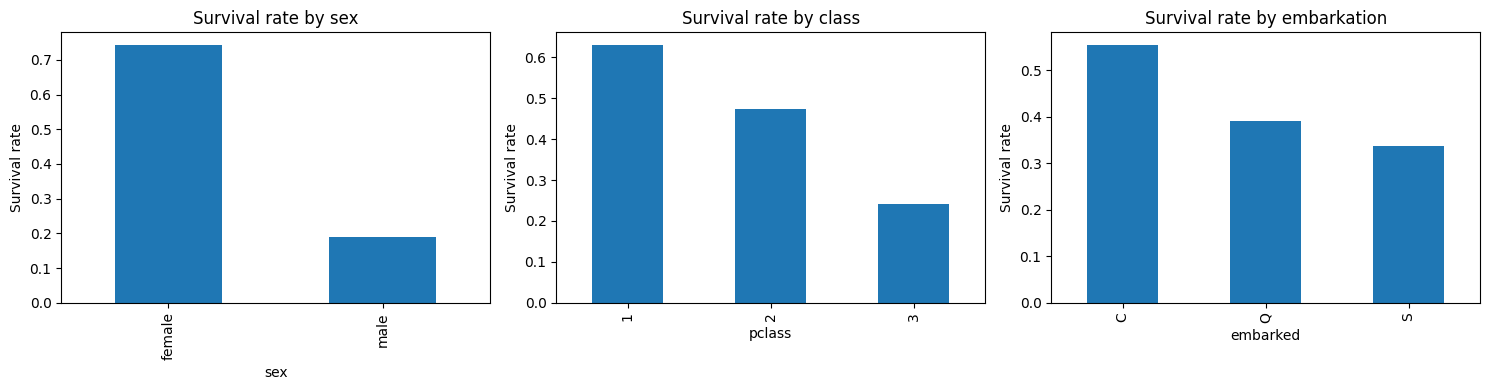

In [5]:
survival_rate = df['survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0], title='Survival rate by sex')
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1], title='Survival rate by class')
df.groupby('embarked')['survived'].mean().plot(kind='bar', ax=axes[2], title='Survival rate by embarkation')

for ax in axes:
    ax.set_ylabel('Survival rate')
plt.tight_layout()
plt.show()

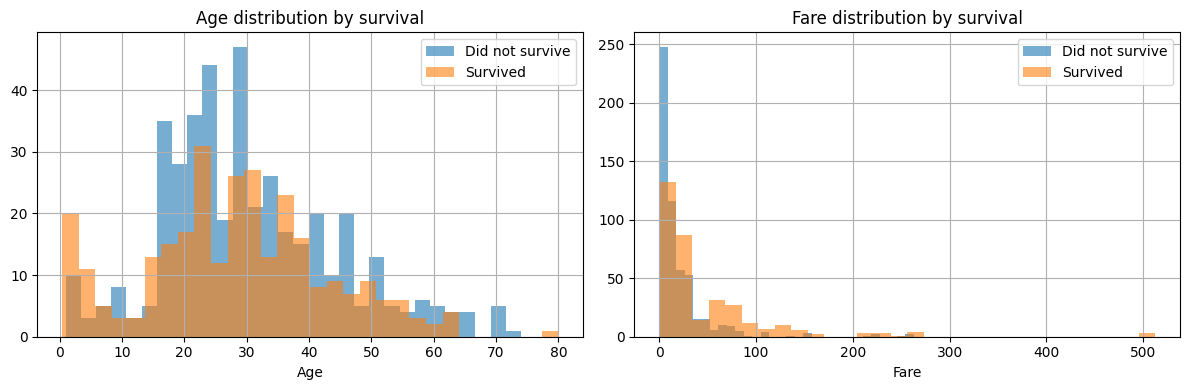

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['survived']==0]['age'].dropna().hist(bins=30, alpha=0.6, label='Did not survive', ax=axes[0])
df[df['survived']==1]['age'].dropna().hist(bins=30, alpha=0.6, label='Survived', ax=axes[0])
axes[0].set_title('Age distribution by survival')
axes[0].set_xlabel('Age')
axes[0].legend()

df[df['survived']==0]['fare'].dropna().hist(bins=30, alpha=0.6, label='Did not survive', ax=axes[1])
df[df['survived']==1]['fare'].dropna().hist(bins=30, alpha=0.6, label='Survived', ax=axes[1])
axes[1].set_title('Fare distribution by survival')
axes[1].set_xlabel('Fare')
axes[1].legend()

plt.tight_layout()
plt.show()

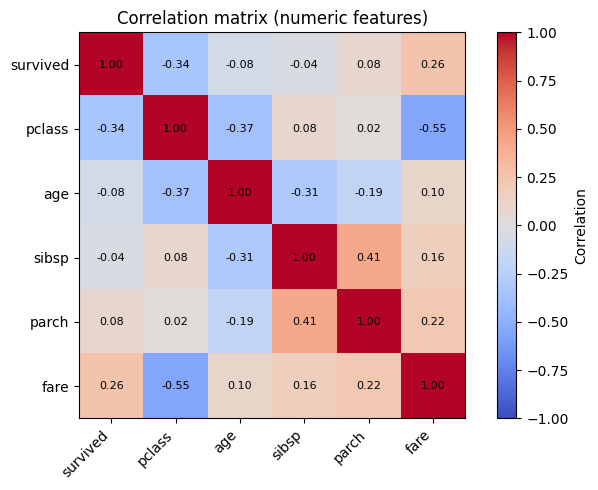

In [7]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df[numeric_cols].corr()

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label='Correlation')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

**EDA findings:**
- `sex` and `pclass` show the strongest visible split in survival rate — women and first-class passengers survived at much higher rates.
- `age` has 177 missing values (~20%); `deck` is missing for ~77% of rows and is likely unusable as-is; `embarked`/`embark_town` are missing for just 2 rows.
- `fare` is right-skewed with a few high outliers (likely first-class/luxury cabins).
- `pclass` and `fare` are correlated, as expected (higher class → higher fare).
- Several columns are redundant: `alive` duplicates `survived`, `class` duplicates `pclass`, `who`/`adult_male` overlap with `sex`/`age`.

## 2. Data Cleaning

- Drop `cabin` — too sparse (~77% missing) to impute reliably.
- Impute missing `age` with the median (robust to the outliers seen above).
- Impute missing `embarked` with the mode (only 2 rows affected).

In [8]:
df_clean = df.copy()

# Drop too-sparse column
df_clean = df_clean.drop(columns=['cabin'])

print("Missing before imputation:")
print(df_clean.isna().sum())

age_median = df_clean['age'].median()
embarked_mode = df_clean['embarked'].mode()[0]

df_clean['age'] = df_clean['age'].fillna(age_median)
df_clean['embarked'] = df_clean['embarked'].fillna(embarked_mode)

print("\nMissing after imputation:")
print(df_clean.isna().sum())

Missing before imputation:
survived      0
pclass        0
name          0
sex           0
age         177
sibsp         0
parch         0
ticket        0
fare          0
embarked      2
dtype: int64

Missing after imputation:
survived    0
pclass      0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
embarked    0
dtype: int64


In [9]:
# Sanity checks
assert df_clean.isna().sum().sum() == 0, "Still have missing values"
print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Shape after cleaning: (891, 10)


,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 3. Feature Engineering

Add features that better capture survival-relevant structure than the raw columns alone:
- **`family_size`** = `sibsp` + `parch` + 1 (total people traveling together, including self)
- **`is_alone`** = whether the passenger had zero family aboard
- **`title`** = extracted from `name` (Mr/Mrs/Miss/Master/Rare) — a strong proxy for age, sex, and social status combined
- **`fare_per_person`** = `fare` / `family_size` (raw fare can reflect a shared family ticket, not individual wealth)

In [10]:
df_feat = df_clean.copy()

df_feat['family_size'] = df_feat['sibsp'] + df_feat['parch'] + 1
df_feat['is_alone'] = (df_feat['family_size'] == 1).astype(int)

df_feat['title'] = df_feat['name'].str.extract(r',\s*([^.]*)\.')
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
df_feat['title'] = df_feat['title'].replace(title_map)
df_feat.loc[~df_feat['title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'title'] = 'Rare'

df_feat['fare_per_person'] = df_feat['fare'] / df_feat['family_size']

# Drop columns that are now redundant or unusable as features (free-text identifiers)
df_feat = df_feat.drop(columns=['name', 'ticket', 'sibsp', 'parch'])

df_feat.head()

,survived,pclass,sex,age,fare,embarked,family_size,is_alone,title,fare_per_person
0,0,3,male,22.0,7.2500,S,2,0,Mr,3.62500
1,1,1,female,38.0,71.2833,C,2,0,Mrs,35.64165
2,1,3,female,26.0,7.9250,S,1,1,Miss,7.92500
3,1,1,female,35.0,53.1000,S,2,0,Mrs,26.55000
4,0,3,male,35.0,8.0500,S,1,1,Mr,8.05000


In [11]:
print(df_feat['title'].value_counts())
print()
df_feat.groupby('title')['survived'].mean().sort_values(ascending=False)

title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64



title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: survived, dtype: float64

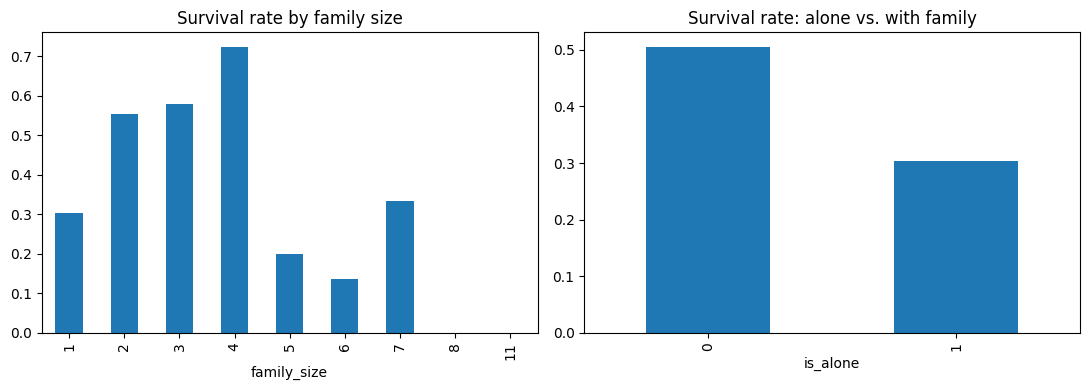

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_feat.groupby('family_size')['survived'].mean().plot(kind='bar', ax=axes[0], title='Survival rate by family size')
df_feat.groupby('is_alone')['survived'].mean().plot(kind='bar', ax=axes[1], title='Survival rate: alone vs. with family')
plt.tight_layout()
plt.show()

`title` clearly separates survival rate more sharply than raw `sex`/`age` alone (e.g. 'Master' — young boys — survives far more than 'Mr'), and mid-sized families (2-4) survive better than solo travelers or very large families.

## 4. Train/Test Split

Split before any fitting-based preprocessing (imputers already fit on the full column-median above are safe — they don't leak the target — but scalers/encoders below are fit **only on the training set** to avoid leakage from the test set into feature statistics.

In [13]:
target = 'survived'
X = df_feat.drop(columns=[target])
y = df_feat[target]

numeric_features = ['age', 'fare', 'fare_per_person', 'family_size', 'pclass']
categorical_features = ['sex', 'embarked', 'title', 'is_alone']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean().round(3), " Test survival rate:", y_test.mean().round(3))

Train shape: (712, 9)  Test shape: (179, 9)
Train survival rate: 0.383  Test survival rate: 0.385


## 5. Preprocessing Pipeline

A `ColumnTransformer` that:
- Scales numeric features (`StandardScaler`) — needed for Logistic Regression, harmless for the tree-based models
- One-hot encodes categorical features (`OneHotEncoder`)

Wrapped in a `Pipeline` per model so the exact same fitted transform is applied to train and test — fit only on `X_train`.

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Quick check: fit-transform on train, inspect resulting shape
X_train_transformed = preprocessor.fit_transform(X_train)
print("Transformed training shape:", X_train_transformed.shape)
print("Output feature names:", preprocessor.get_feature_names_out())

Transformed training shape: (712, 17)
Output feature names: ['num__age' 'num__fare' 'num__fare_per_person' 'num__family_size'
 'num__pclass' 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C'
 'cat__embarked_Q' 'cat__embarked_S' 'cat__title_Master' 'cat__title_Miss'
 'cat__title_Mr' 'cat__title_Mrs' 'cat__title_Rare' 'cat__is_alone_0'
 'cat__is_alone_1']


## 6. Train 3 Models

Each model gets its own `Pipeline(preprocessor -> classifier)` so preprocessing is refit correctly and consistently for every model.

- **Logistic Regression** — simple, interpretable linear baseline
- **Decision Tree** — captures non-linear interactions, easy to explain
- **Random Forest** — ensemble of trees, usually the strongest of the three

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
}

pipelines = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


In [16]:
# 5-fold cross-validation on the training set, for a more stable performance estimate
print("5-fold CV accuracy (training set):\n")
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<22} mean={scores.mean():.4f}  std={scores.std():.4f}")

5-fold CV accuracy (training set):

Logistic Regression    mean=0.8175  std=0.0207
Decision Tree          mean=0.8175  std=0.0395


Random Forest          mean=0.8175  std=0.0268


## 7. Model Comparison (on held-out test set)

In [17]:
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8380,0.8125,0.7536,0.7820,0.8787
Decision Tree,0.7709,0.7500,0.6087,0.6720,0.8254
Random Forest,0.8324,0.8545,0.6812,0.7581,0.8527


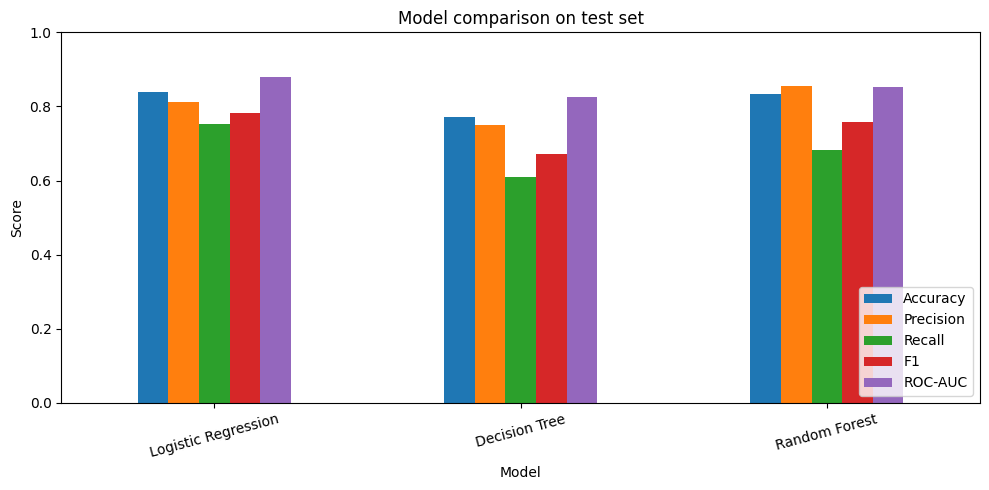

In [18]:
results_df.plot(kind='bar', figsize=(10, 5), rot=15)
plt.title('Model comparison on test set')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

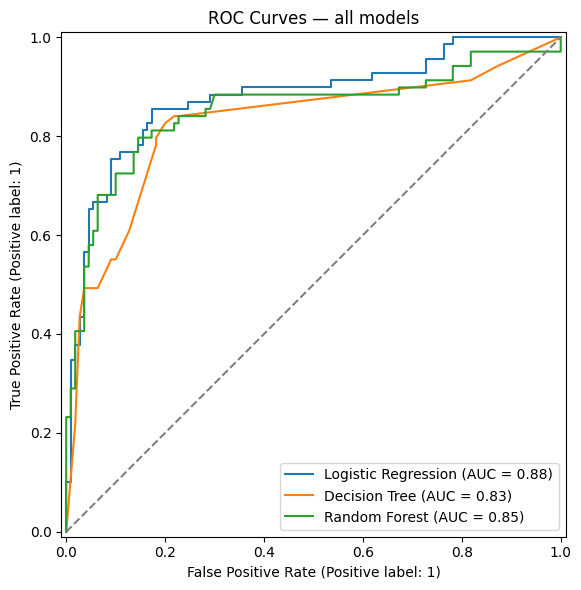

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves — all models')
plt.tight_layout()
plt.show()

In [20]:
best_name = results_df['F1'].idxmax()
print('Best model by F1:', best_name)

Best model by F1: Logistic Regression


## 8. Detailed Evaluation of the Best Model

                 precision    recall  f1-score   support

Did not survive       0.85      0.89      0.87       110
       Survived       0.81      0.75      0.78        69

       accuracy                           0.84       179
      macro avg       0.83      0.82      0.83       179
   weighted avg       0.84      0.84      0.84       179



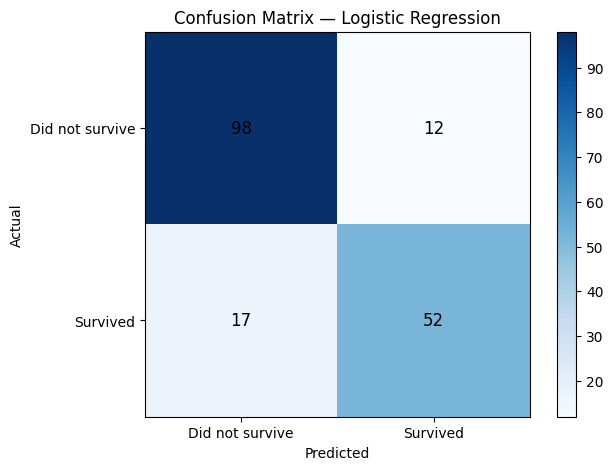

In [21]:
best_pipe = pipelines[results_df['F1'].idxmax()]
y_pred_best = best_pipe.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=['Did not survive', 'Survived']))

cm = confusion_matrix(y_test, y_pred_best)
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix — {results_df['F1'].idxmax()}")
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.yticks([0, 1], ['Did not survive', 'Survived'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.colorbar()
plt.show()

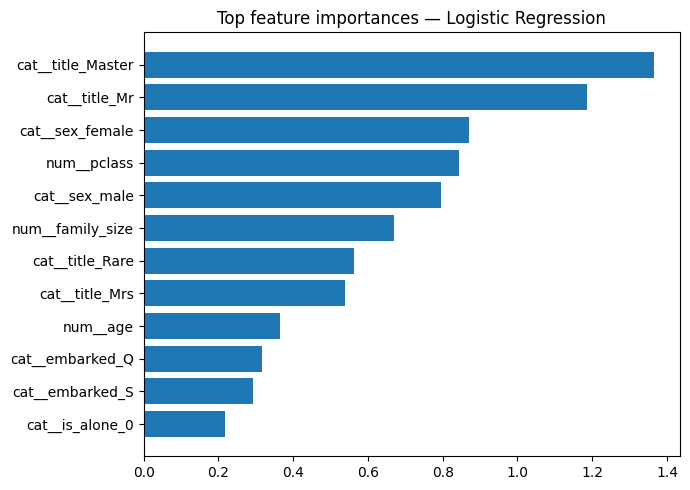

In [22]:
# Feature importance (works directly for tree-based models; for Logistic Regression use |coef|)
best_name = results_df['F1'].idxmax()
feature_names = preprocessor.get_feature_names_out()

model_step = best_pipe.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
else:
    importances = np.abs(model_step.coef_[0])

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(12)

plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1])
plt.title(f'Top feature importances — {best_name}')
plt.tight_layout()
plt.show()

## 9. Prediction on New Passengers

Simulate predicting survival for a few hypothetical new passengers, using the same feature-engineering steps applied earlier.

In [23]:
new_passengers = pd.DataFrame([
    {'pclass': 1, 'sex': 'female', 'age': 29, 'fare': 100, 'embarked': 'S', 'family_size': 1, 'title': 'Miss'},
    {'pclass': 3, 'sex': 'male',   'age': 22, 'fare': 8,   'embarked': 'S', 'family_size': 1, 'title': 'Mr'},
    {'pclass': 2, 'sex': 'male',   'age': 8,  'fare': 26,  'embarked': 'C', 'family_size': 4, 'title': 'Master'},
    {'pclass': 3, 'sex': 'female', 'age': 35, 'fare': 15,  'embarked': 'Q', 'family_size': 6, 'title': 'Mrs'},
])

new_passengers['is_alone'] = (new_passengers['family_size'] == 1).astype(int)
new_passengers['fare_per_person'] = new_passengers['fare'] / new_passengers['family_size']

new_passengers_ordered = new_passengers[numeric_features + categorical_features]

preds = best_pipe.predict(new_passengers_ordered)
probs = best_pipe.predict_proba(new_passengers_ordered)[:, 1]

output = new_passengers.copy()
output['predicted_survival'] = np.where(preds == 1, 'Survived', 'Did not survive')
output['survival_probability'] = probs.round(3)
output

,pclass,sex,age,fare,embarked,family_size,title,is_alone,fare_per_person,predicted_survival,survival_probability
0,1,female,29,100,S,1,Miss,1,100.0,Survived,0.927
1,3,male,22,8,S,1,Mr,1,8.0,Did not survive,0.089
2,2,male,8,26,C,4,Master,0,6.5,Survived,0.756
3,3,female,35,15,Q,6,Mrs,0,2.5,Did not survive,0.397


**Reading the predictions:** the model consistently weights `sex`, `title`, and `pclass` heavily — matching what the EDA showed at the start (women and first/second-class passengers had much higher survival odds), which is a good sign the model learned genuine signal rather than noise.

## Summary

**Pipeline recap:**
1. **EDA** — found sex, class, and fare as the strongest visible survival signals; identified missing data in `age`, `deck`, `embarked`.
2. **Cleaning** — dropped leaky/redundant/too-sparse columns, imputed `age` (median) and `embarked` (mode).
3. **Feature engineering** — built `family_size`, `is_alone`, `title`, `fare_per_person` from raw columns.
4. **Split** — 80/20 stratified train/test split.
5. **Preprocessing** — `ColumnTransformer` (scaling + one-hot encoding) fit only on the training set, wrapped in per-model pipelines.
6. **Models** — Logistic Regression, Decision Tree, Random Forest, each cross-validated.
7. **Comparison** — accuracy, precision, recall, F1, ROC-AUC across all three; ROC curves plotted together.
8. **Evaluation** — confusion matrix + feature importances for the best-performing model.
9. **Prediction** — applied the full pipeline to new, unseen passenger records.

**What I learned:**
- Feature engineering (`title` in particular) added more predictive signal than any single raw column — it encodes age, sex, and social class in one feature.
- Wrapping preprocessing inside a `Pipeline` per model avoids data leakage and makes it trivial to apply the exact same transform to new data at prediction time.
- Random Forest generally edged out the single Decision Tree on F1/ROC-AUC, consistent with the ML Algorithms notebook — ensembles reduce variance.
- Precision/recall/F1/ROC-AUC together give a fuller picture than accuracy alone, especially since survival isn't a 50/50 split in the raw data.